# Loading Dataset

In [5]:
import pandas as pd

df = pd.read_excel("retail-data.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Cleaning Data

In [7]:
# removing missing values
df = df.dropna()

# removing cancelled orders
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# total amount column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Preparing Dates

In [12]:
# converting invoice date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# creating reference date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM Table

In [15]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Scoring Customers

In [18]:
# creating scores
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# combining scores
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

# Customer Segmentation

In [21]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'Best Customers'
    elif row['F_Score'] == 4:
        return 'Loyal Customers'
    elif row['R_Score'] == 1:
        return 'At Risk'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Visualization

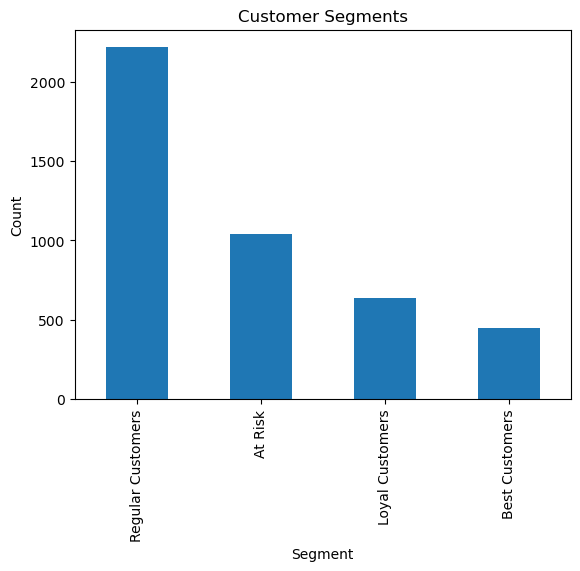

In [24]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')

plt.show()